<a href="https://colab.research.google.com/github/LOVELY1907/SAP_AI-ML-DL/blob/main/03_Deep_Learning/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
#Data Ingestion
df = pd.read_csv('/content/patient_churn_dataset.csv')

In [ ]:
df.sample(5)

,Patient_ID,Age,Gender,Tenure_Months,Visits_Last_Year,Chronic_Disease,Insurance_Type,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn
183,184,56,Male,26,3,No,Private,1.9,48337.66,2,0
104,105,48,Male,30,7,Yes,Private,3.0,34778.39,6,0
258,259,41,Male,18,1,No,NaN,3.9,10929.90,3,0
416,417,50,Female,25,11,Yes,Government,3.6,17198.60,8,1
497,498,67,Male,31,19,Yes,Government,3.5,47917.74,1,0


In [ ]:
df.shape

(500, 11)

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Tenure_Months,0
Visits_Last_Year,0
Chronic_Disease,0
Insurance_Type,150
Satisfaction_Score,0
Total_Bill_Amount,0
Missed_Appointments,0


In [ ]:
#removing the patient id
if 'Patient_ID' in df.columns:
  df.drop('Patient_ID',axis=1, inplace=True)

In [ ]:
df.columns.tolist()

['Age',
 'Gender',
 'Tenure_Months',
 'Visits_Last_Year',
 'Chronic_Disease',
 'Insurance_Type',
 'Satisfaction_Score',
 'Total_Bill_Amount',
 'Missed_Appointments',
 'Churn']

In [ ]:
#pipeline 1st procedure
X = df.drop('Churn',axis=1)
Y = df['Churn']

In [ ]:
from pandas.core.arrays import categorical
#pipleline 2nd procedure
numerical_cols = X.select_dtypes(
    include=['int64','float64']).columns

categorical_cols = X.select_dtypes(
    include=['object']).columns

In [ ]:
numerical_cols.tolist()

['Age',
 'Tenure_Months',
 'Visits_Last_Year',
 'Satisfaction_Score',
 'Total_Bill_Amount',
 'Missed_Appointments']

In [ ]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')

X[['Insurance_Type']] = si.fit_transform(X[['Insurance_Type']])

In [ ]:
num_columns_transformer = Pipeline(
    steps =[
        ('scaler', StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps = [
        ('encoding', OneHotEncoder(sparse_output=False))
    ]
)

In [ ]:
X['Insurance_Type'].isnull().sum()

np.int64(0)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_transformer,categorical_cols),
        ('numerical', num_columns_transformer,numerical_cols)
    ]
)

In [ ]:
model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('Classifier',LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2, random_state=100, stratify= Y)

In [ ]:
X_train

,Age,Gender,Tenure_Months,Visits_Last_Year,Chronic_Disease,Insurance_Type,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments
65,31,Male,28,6,Yes,Private,4.0,34486.20,5
349,42,Female,11,13,Yes,Government,3.5,13884.47,1
142,34,Male,57,18,No,Private,2.2,34569.57,8
39,76,Male,5,13,No,Government,1.7,31044.79,6
210,49,Male,26,1,No,Private,4.5,6678.63,9
...,...,...,...,...,...,...,...,...,...
328,77,Male,26,1,Yes,Private,3.3,13934.76,6
265,58,Female,8,9,Yes,Government,4.9,1208.61,7
94,71,Male,2,18,No,Government,1.7,15104.52,4
90,23,Female,15,18,Yes,Government,4.4,26931.39,0


In [ ]:
Y_train

,Churn
65,0
349,0
142,0
39,1
210,0
...,...
328,0
265,0
94,0
90,1


In [ ]:
#model Pipeline training
model.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  Index(['Gender', 'Chronic_Disease', 'Insurance_Type'], dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Tenure_Months', 'Visits_Last_Year', 'Satisfaction_Score',
       'Total_Bill_Amount', 'Missed_Appointments'],
      dtype='object'))])),
                ('Classifier', LogisticRegression(max_iter=1000))])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,model.predict(X_test))

0.75

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

In [ ]:
num_columns_transformer1 = Pipeline(
    steps =[
        ('scaler', StandardScaler())
    ]
)
categorical_transformer1 = Pipeline(
    steps = [
        ('encoding', OneHotEncoder(sparse_output=False))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers =[
        ('categorical',
         categorical_transformer,categorical_cols),
        ('numerical',
         num_columns_transformer,numerical_cols)
    ]
)

In [ ]:
model = Pipeline(
    steps =[
        ('preprocessor',preprocessor),
        ('classifier',KNeighborsClassifier(n_neighbors=3,metric='euclidean'))
    ]
)

In [ ]:
#training as testing
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=100,stratify=Y)

In [ ]:
#model pipeline training
model.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  Index(['Gender', 'Chronic_Disease', 'Insurance_Type'], dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Tenure_Months', 'Visits_Last_Year', 'Satisfaction_Score',
       'Total_Bill_Amount', 'Missed_Appointments'],
      dtype='object'))])),
                ('classifier',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=3))])

In [ ]:
accuracy_score(Y_test,model.predict(X_test))

0.65

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
Score=cross_val_score(model,X,Y,cv=5)
mean=Score.mean()
max=Score.max()
min=Score.min()
print(mean)
print(max)
print(min)

0.672
0.74
0.58


In [ ]:
Score

array([0.69, 0.7 , 0.65, 0.74, 0.58])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model

In [ ]:
ohe = OneHotEncoder(sparse_output=False)
X['Chronic_Disease'] = ohe.fit_transform(X[['Chronic_Disease']])
X['Gender'] = ohe.fit_transform(X[['Gender']])
X['Insurance_Type'] = ohe.fit_transform(X[['Insurance_Type']])

In [ ]:
#training as testing
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape[1]

9

In [ ]:
#creating a ANN network
ANN1 = Sequential()
#input layer
ANN1.add(layers.Dense(64, activation='relu',input_shape=(X_train.shape[1],)))

#Hidden layer
ANN1.add(layers.Dense(32, activation='relu'))

#output layer
ANN1.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
ANN1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Reconstruct X and y correctly from the original dataframe
# Assuming df is the dataframe after 'Patient_ID' removal
X = df.drop('Churn', axis=1).copy()
y = df['Churn']

# Impute 'Insurance_Type' first, as done previously
si = SimpleImputer(strategy='most_frequent')
X['Insurance_Type'] = si.fit_transform(X[['Insurance_Type']]).flatten()

# Identify numerical and categorical columns from the current X
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

# Apply the preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42)

# Ensure y_train is a numpy array if it's still a pandas Series, for consistency with Keras
if isinstance(y_train, pd.Series):
    y_train = y_train.values

# Re-create and compile the ANN model to ensure the input shape matches the processed data
# This assumes the original model structure was intended. The input_shape will now be dynamic.
ANN1 = Sequential()
ANN1.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
ANN1.add(layers.Dense(32, activation='relu'))
ANN1.add(layers.Dense(1, activation='sigmoid'))

ANN1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training Code for Neural Network
ANN1_history = ANN1.fit(X_train, y_train, epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2361 - loss: 0.9127
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6464 - loss: 0.6538 
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7419 - loss: 0.5885
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7747 - loss: 0.5336
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7396 - loss: 0.5654  
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7720 - loss: 0.5269 
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7719 - loss: 0.5228 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7515 - loss: 0.5410 
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7514 - loss: 0.5378 
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7569 - loss: 0.5354 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7316 - loss: 0.5525 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7779 - los

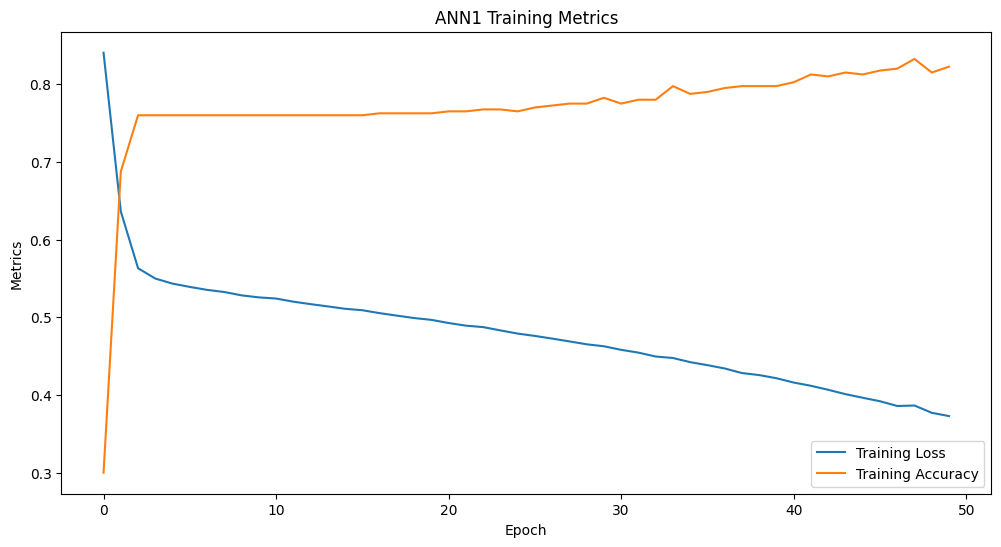

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ANN1_history.history['loss'], label='Training Loss')
plt.plot(ANN1_history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.title('ANN1 Training Metrics')
plt.legend()
plt.show()

In [ ]:
#creating a ANN network
ANN2 = Sequential()
#input layer
ANN2.add(layers.Dense(64, activation='relu',input_shape=(X_train.shape[1],)))

#Hidden layer
ANN2.add(layers.Dense(32, activation='relu'))
ANN2.add(layers.Dense(16, activation='relu'))

#output layer
ANN2.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
ANN2_history = ANN2.fit(X_train,y_train,epochs=100,validation_data=(X_test, y_test))

ValueError: You must call `compile()` before using the model.

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ANN2_history.history['loss'], label='Training Loss')
plt.plot(ANN2_history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.title('ANN2 Training Metrics')
plt.legend()
plt.show()

NameError: name 'ANN2_history' is not defined

<Figure size 1200x600 with 0 Axes>